ファイルを読み込みます: G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data/combined_EyeCenterAngle_saccade_analysis_15_4567815161718_umap_nofreq.csv
,区切りファイルとして読み込みます
データ読み込み完了: 177行, 24列
特徴量として使用: 23列
UMAPによる次元削減を実行中...


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP次元削減完了
エルボー法による分析を実行中...
クラスター数 2: イナーシャ = 439.37, シルエットスコア = 0.4718
クラスター数 3: イナーシャ = 261.84, シルエットスコア = 0.4684
クラスター数 4: イナーシャ = 170.84, シルエットスコア = 0.4594
クラスター数 5: イナーシャ = 129.87, シルエットスコア = 0.4488


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

クラスター数 6: イナーシャ = 101.44, シルエットスコア = 0.4617
クラスター数 7: イナーシャ = 84.28, シルエットスコア = 0.4421
クラスター数 8: イナーシャ = 70.42, シルエットスコア = 0.4622
シルエットスコアに基づく分析: クラスター数 2 が最大値 0.4718


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-means clustering (k=2)を実行中...
クラスター 0: 56 データポイント
クラスター 1: 33 データポイント
クラスター 2: 41 データポイント
クラスター 3: 47 データポイント
すべてのポイントにIDを表示中...


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


ラベルの重なりを調整してすべてのポイントにIDを表示中...
ラベルの重なり回避機能が使えません。pip install adjustTextでインストールできます。
エルボー法の図を保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\elbow_method_no_recommendation.png
すべてのIDを表示したプロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_kmeans_k2_all_ids.png
ラベルの重なりを調整したプロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_kmeans_k2_all_ids_adjusted.png
解析結果をCSVに保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_clustered_data_k2.csv
処理完了!


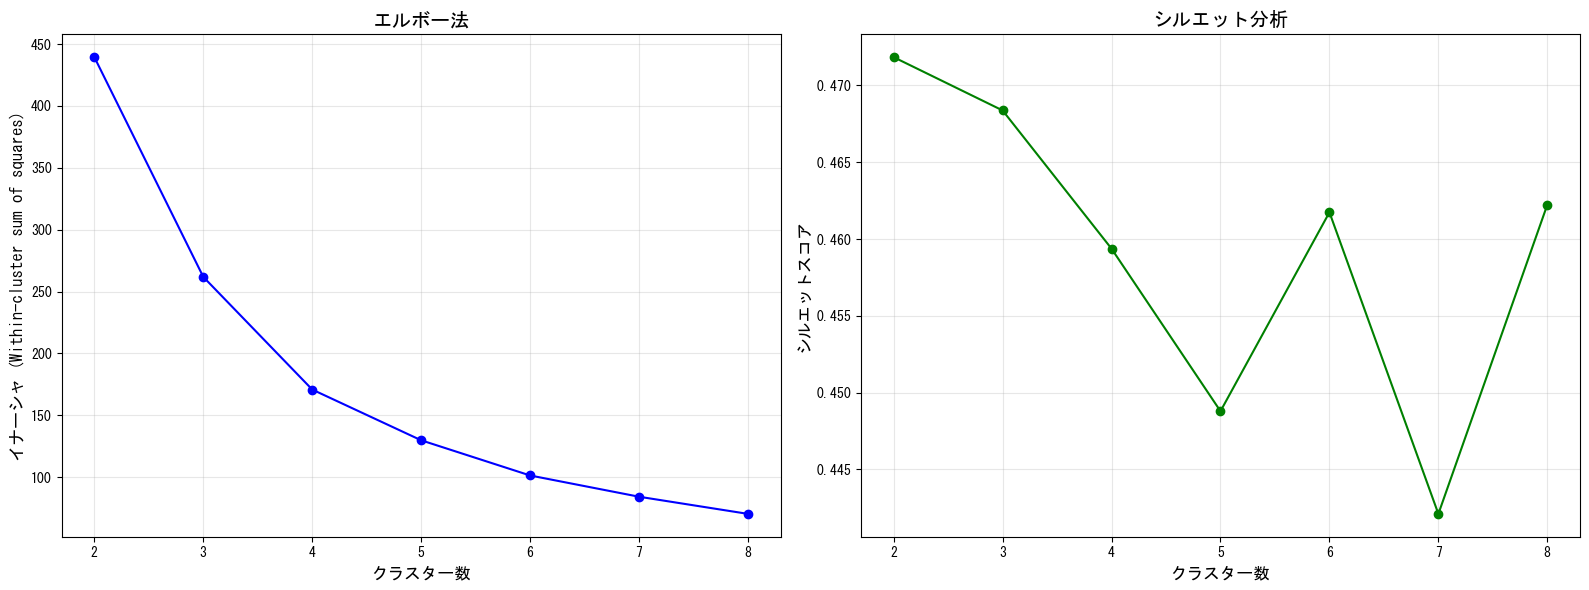

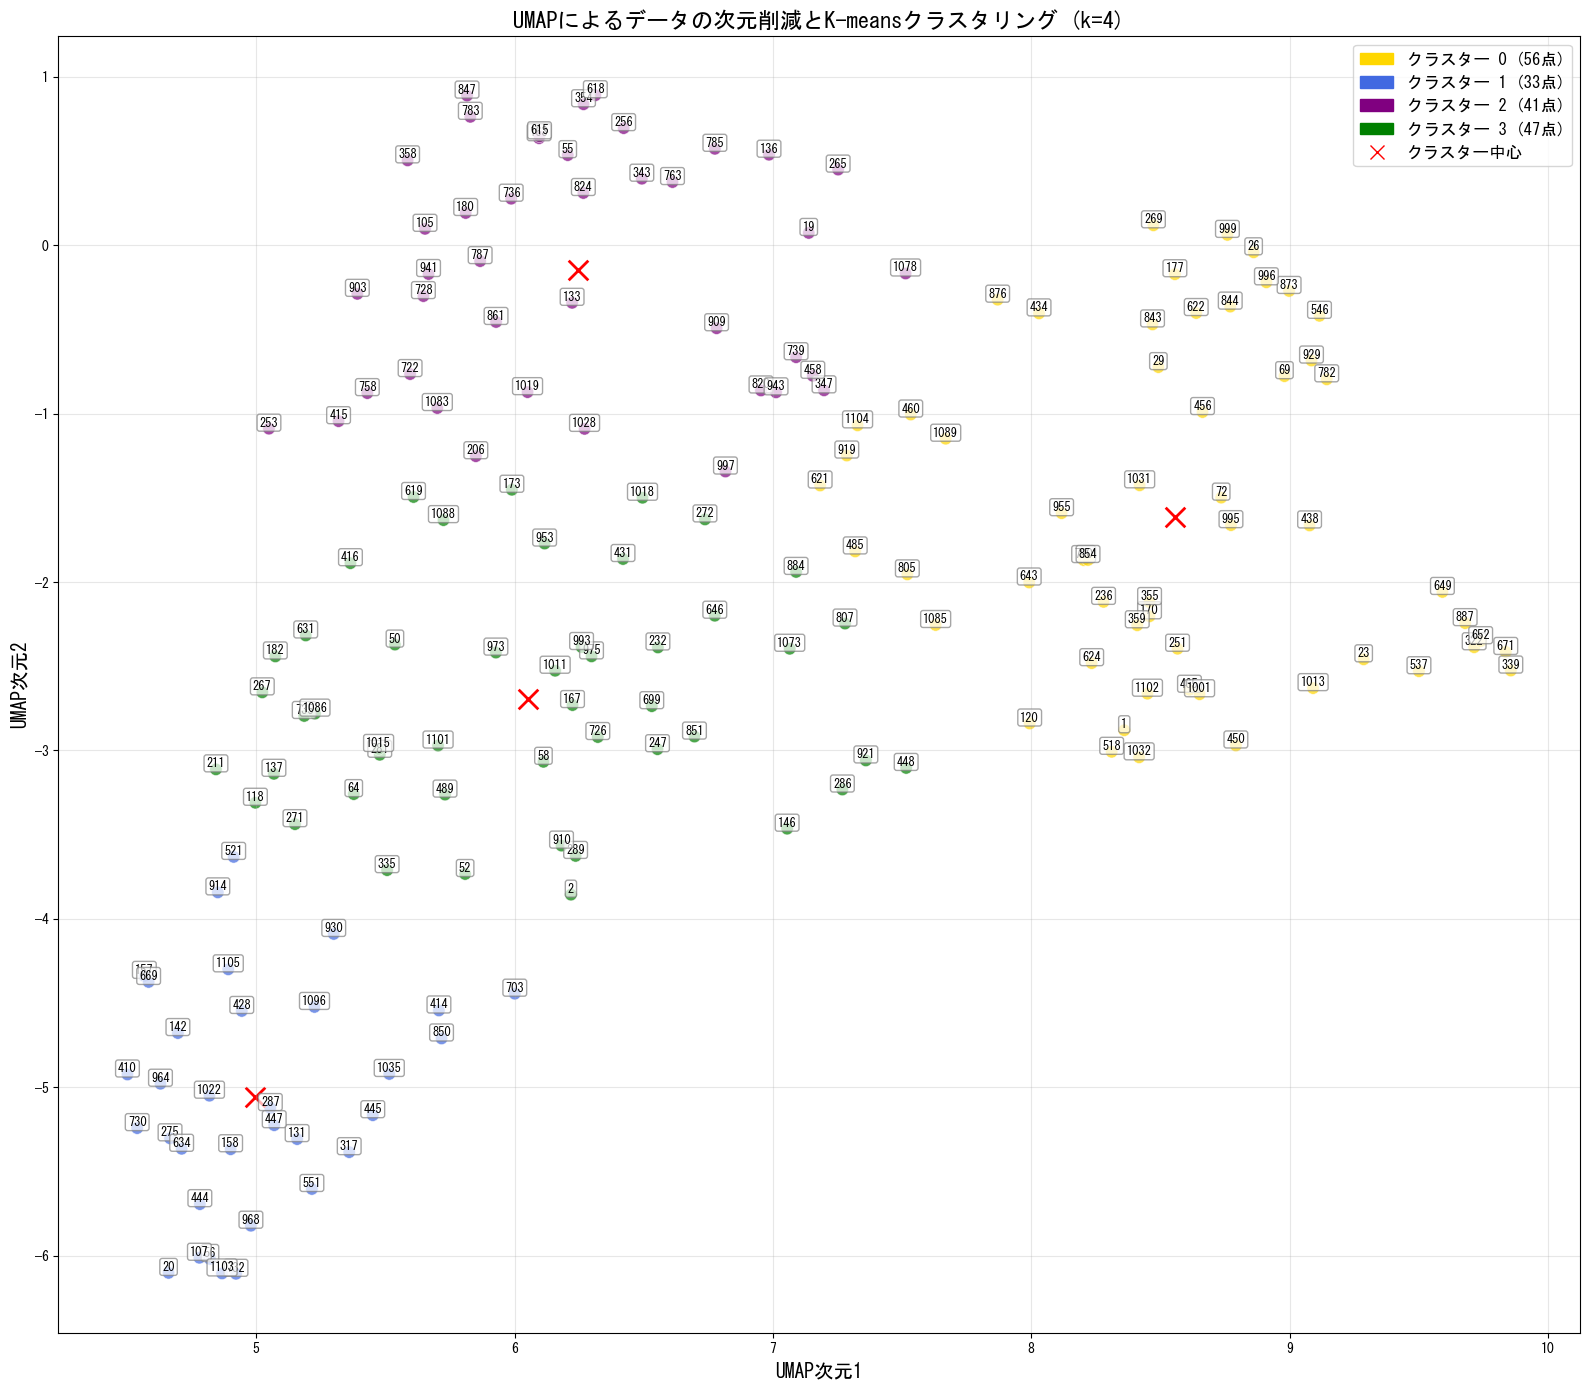

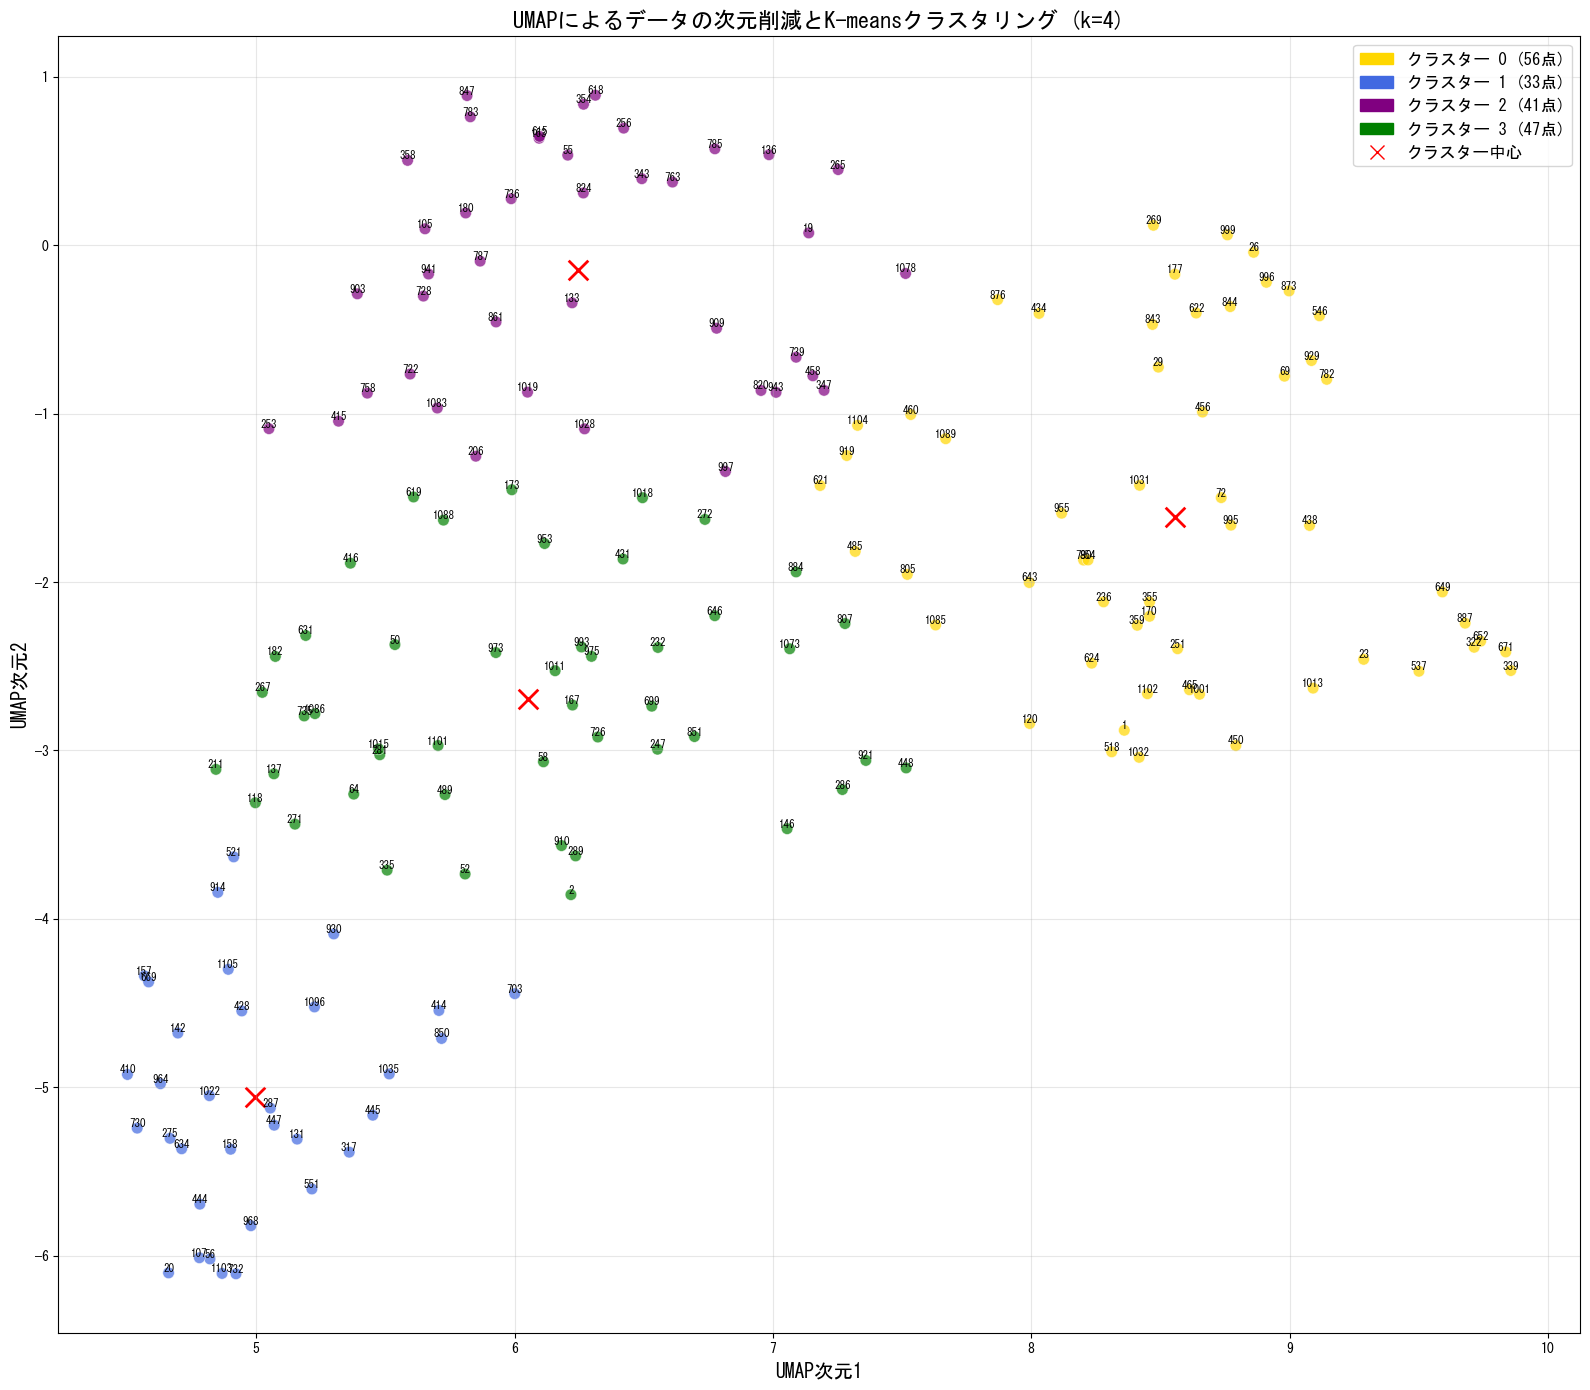

In [ ]:
%matplotlib inline
# 対話的な表示が必要な場合は %matplotlib widget に変更してください

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from umap import UMAP
import matplotlib.patches as mpatches
import os
from sklearn.metrics import silhouette_score

# 日本語フォント設定（必要に応じて）
try:
    import matplotlib.font_manager as fm
    font_path = 'C:/Windows/Fonts/msgothic.ttc'  # Windowsの場合のMSゴシック
    if os.path.exists(font_path):
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rcParams['font.family'] = prop.get_name()
except Exception:
    pass  # フォント設定に失敗しても処理を続行

# ファイルパスの設定
path = "G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data"
file_path = f"{path}/jcombined_EyeCenterAngle_sens15_excl5s_vel30_angle_std.csv"

print(f"ファイルを読み込みます: {file_path}")

# ファイルの読み込みと前処理
try:
    # 区切り文字を検出
    with open(file_path, 'r') as f:
        first_line = f.readline().strip()
        
    separator = '\t' if '\t' in first_line else (',' if ',' in first_line else '\t')
    print(f"{separator}区切りファイルとして読み込みます")
    
    # CSVファイルの読み込み
    df = pd.read_csv(file_path, sep=separator)
    print(f"データ読み込み完了: {df.shape[0]}行, {df.shape[1]}列")
    
    # 列が1つだけの場合の処理
    if df.shape[1] == 1:
        print("列が1つだけです。カンマ区切りでの再分割を試みます")
        first_col_name = df.columns[0]
        if ',' in str(df[first_col_name].iloc[0]):
            temp_df = df[first_col_name].str.split(',', expand=True)
            headers = temp_df.iloc[0]
            temp_df = temp_df.iloc[1:]
            temp_df.columns = headers
            df = temp_df
            print("カンマ区切りで再分割しました")
    
    # 数値列に変換
    for col in df.columns:
        if col not in ['freq', 'power_spectrum', 'InspectionDateAndId']:
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                pass
    
    # 数値列のみを選択
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print(f"特徴量として使用: {len(numeric_cols)}列")
    
    # 特徴量が空の場合はエラー
    if not numeric_cols:
        raise ValueError("数値特徴量が見つかりません")
    
    # 数値データを抽出
    X = df[numeric_cols].copy()
    X = X.fillna(X.mean())  # 欠損値を平均値で補完
    
    # 標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # UMAP次元削減
    print("UMAPによる次元削減を実行中...")
    reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    print("UMAP次元削減完了")
    
except FileNotFoundError:
    print(f"エラー: ファイル '{file_path}' が見つかりません。")
    raise
except Exception as e:
    print(f"エラー: {str(e)}")
    raise

# ========================
# エルボー法（推奨表示なし）
# ========================

def plot_elbow_method_no_recommendation(X, max_clusters=10):
    """
    エルボー法とシルエットスコアによるクラスター数の分析
    （推奨表示なし）
    
    Parameters:
    -----------
    X : numpy.ndarray
        クラスタリングするデータ (UMAP埋め込み)
    max_clusters : int
        検証する最大クラスター数
    
    Returns:
    --------
    k_for_clustering : int
        使用するクラスター数
    fig : matplotlib.figure.Figure
        エルボー法とシルエットスコアのプロット
    """
    # クラスター数ごとのイナーシャ（慣性）とシルエットスコアを計算
    print("エルボー法による分析を実行中...")
    inertia_values = []
    silhouette_values = []
    k_values = range(2, max_clusters + 1)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia_values.append(kmeans.inertia_)
        
        # 2クラスター以上の場合にシルエットスコアを計算
        labels = kmeans.labels_
        silhouette_values.append(silhouette_score(X, labels))
        print(f"クラスター数 {k}: イナーシャ = {kmeans.inertia_:.2f}, シルエットスコア = {silhouette_values[-1]:.4f}")
    
    # クラスター数の設定（シルエットスコアが最大のもの）
    k_for_clustering = k_values[np.argmax(silhouette_values)]
    print(f"シルエットスコアに基づく分析: クラスター数 {k_for_clustering} が最大値 {np.max(silhouette_values):.4f}")
    
    # プロットの作成（2つのサブプロットを含む）
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # イナーシャのプロット（エルボー法）
    ax1.plot(k_values, inertia_values, 'bo-')
    ax1.set_xlabel('クラスター数', fontsize=12)
    ax1.set_ylabel('イナーシャ (Within-cluster sum of squares)', fontsize=12)
    ax1.set_title('エルボー法', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # シルエットスコアのプロット
    ax2.plot(k_values, silhouette_values, 'go-')
    ax2.set_xlabel('クラスター数', fontsize=12)
    ax2.set_ylabel('シルエットスコア', fontsize=12)
    ax2.set_title('シルエット分析', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return k_for_clustering, fig

# ========================
# すべてのポイントにIDを表示する関数
# ========================

def plot_all_points_with_ids(df, embedding, clusters, centers, id_column='InspectionDateAndId',
                             id_type='suffix', fontsize=8, alpha=0.7, point_size=70):
    """
    すべてのポイントにIDを表示してプロットする関数
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム（IDを含む）
    embedding : numpy.ndarray
        UMAPによる2次元埋め込み座標
    clusters : numpy.ndarray
        各ポイントのクラスターID
    centers : numpy.ndarray
        クラスター中心の座標
    id_column : str
        ID列の列名
    id_type : str
        'full'=完全なID, 'suffix'=末尾のみ, 'prefix'=先頭のみ
    fontsize : int
        IDのフォントサイズ
    alpha : float
        ポイントの透明度
    point_size : int
        ポイントのサイズ
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        作成された図のオブジェクト
    ax : matplotlib.axes.Axes
        作成された軸のオブジェクト
    """
    # 図の作成
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # クラスターごとに異なる色でプロット
    colors = ['gold', 'royalblue', 'purple', 'green', 'orange', 'cyan', 'magenta', 'brown', 'gray', 'olive']
    # クラスター数より多い色が必要な場合は繰り返し
    colors = colors * (len(np.unique(clusters)) // len(colors) + 1)
    
    scatter = ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=[colors[c] for c in clusters], 
        s=point_size,
        alpha=alpha,
        edgecolor='white',
        linewidth=0.5
    )
    
    # クラスターの中心を表示
    ax.scatter(
        centers[:, 0], 
        centers[:, 1], 
        marker='x', 
        s=200, 
        c='red', 
        linewidth=2
    )
    
    # IDを表示
    for i, (x, y) in enumerate(embedding):
        full_id = str(df.iloc[i][id_column])
        
        # IDの処理（表示方法に応じて）
        if id_type == 'suffix' and '_' in full_id:
            # '_'で区切られた末尾の部分を表示
            display_id = full_id.split('_')[-1]
        elif id_type == 'prefix' and '_' in full_id:
            # '_'で区切られた先頭の部分を表示
            display_id = full_id.split('_')[0]
        else:
            # 完全なIDを表示
            display_id = full_id
        
        # テキスト追加 - クラスター情報も含める
        cluster_id = clusters[i]
        ax.text(
            x, y, 
            display_id,  # または f"C{cluster_id}:{display_id}" でクラスターIDも表示
            fontsize=fontsize,
            ha='center',  # 水平方向の位置揃え
            va='bottom',  # 垂直方向の位置揃え
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="white",
                ec="gray",
                alpha=0.7
            )
        )
    
    # 凡例の作成
    legend_handles = []
    cluster_counts = np.bincount(clusters)
    for i in range(len(np.unique(clusters))):
        patch = mpatches.Patch(color=colors[i], label=f'クラスター {i} ({cluster_counts[i]}点)')
        legend_handles.append(patch)
    center_marker = matplotlib.lines.Line2D(
        [], [], color='red', marker='x', linestyle='None', 
        markersize=10, label='クラスター中心'
    )
    legend_handles.append(center_marker)
    ax.legend(handles=legend_handles, fontsize=12)
    
    # 軸ラベルとタイトル
    ax.set_xlabel('UMAP次元1', fontsize=14)
    ax.set_ylabel('UMAP次元2', fontsize=14)
    ax.set_title(f'UMAPによるデータの次元削減とK-meansクラスタリング (k={len(np.unique(clusters))})', fontsize=16)
    
    # グリッドとレイアウト
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    return fig, ax

# ========================
# より高度なバージョン - ラベルの重なりを制御
# ========================

def plot_all_points_with_non_overlapping_ids(df, embedding, clusters, centers, id_column='InspectionDateAndId'):
    """
    すべてのポイントにIDを表示し、ラベルの重なりを最小化する
    """
    try:
        # adjust_textライブラリのインポートを試みる
        from adjustText import adjust_text
        has_adjust_text = True
    except ImportError:
        print("Warning: adjustTextライブラリがインストールされていません。")
        print("ラベルの重なり回避機能が使えません。pip install adjustTextでインストールできます。")
        has_adjust_text = False
    
    # 図の作成
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # クラスターごとに異なる色でプロット
    colors = ['gold', 'royalblue', 'purple', 'green', 'orange', 'cyan', 'magenta', 'brown', 'gray', 'olive']
    # クラスター数より多い色が必要な場合は繰り返し
    colors = colors * (len(np.unique(clusters)) // len(colors) + 1)
    
    scatter = ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=[colors[c] for c in clusters], 
        s=70,
        alpha=0.7,
        edgecolor='white',
        linewidth=0.5
    )
    
    # クラスター中心の表示
    ax.scatter(
        centers[:, 0], 
        centers[:, 1], 
        marker='x', 
        s=200, 
        c='red', 
        linewidth=2
    )
    
    # テキスト収集（ラベルの重なりを調整するため）
    texts = []
    for i, (x, y) in enumerate(embedding):
        full_id = str(df.iloc[i][id_column])
        
        # '_'で区切られた末尾の部分を表示
        if '_' in full_id:
            display_id = full_id.split('_')[-1]
        else:
            display_id = full_id
        
        # テキスト追加
        text = ax.text(
            x, y, 
            display_id,
            fontsize=8,
            ha='center',
            va='bottom'
        )
        texts.append(text)
    
    # ラベルの重なりを調整
    if has_adjust_text:
        adjust_text(
            texts,
            force_points=0.2,
            force_text=0.5,
            expand_points=(1.2, 1.2),
            expand_text=(1.2, 1.2),
            arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6, lw=0.5)
        )
    
    # 凡例の作成
    legend_handles = []
    cluster_counts = np.bincount(clusters)
    for i in range(len(np.unique(clusters))):
        patch = mpatches.Patch(color=colors[i], label=f'クラスター {i} ({cluster_counts[i]}点)')
        legend_handles.append(patch)
    center_marker = matplotlib.lines.Line2D(
        [], [], color='red', marker='x', linestyle='None', 
        markersize=10, label='クラスター中心'
    )
    legend_handles.append(center_marker)
    ax.legend(handles=legend_handles, fontsize=12)
    
    # 軸ラベルとタイトル
    ax.set_xlabel('UMAP次元1', fontsize=14)
    ax.set_ylabel('UMAP次元2', fontsize=14)
    ax.set_title(f'UMAPによるデータの次元削減とK-meansクラスタリング (k={len(np.unique(clusters))})', fontsize=16)
    
    # グリッドとレイアウト
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    return fig, ax

# ========================
# 処理の実行
# ========================

# 1. エルボー法による分析（推奨表示なし）
k_for_clustering, elbow_fig = plot_elbow_method_no_recommendation(embedding, max_clusters=8)

# 2. K-meansクラスタリングを実行
print(f"K-means clustering (k={k_for_clustering})を実行中...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embedding)

# クラスター情報をデータフレームに追加
df['cluster'] = clusters

# クラスターの中心座標
centers = kmeans.cluster_centers_

# クラスターごとのデータ点数
cluster_counts = np.bincount(clusters)
for i, count in enumerate(cluster_counts):
    print(f"クラスター {i}: {count} データポイント")

# 3. 通常バージョン - すべてのポイントに直接IDを表示
print("すべてのポイントにIDを表示中...")
fig1, ax1 = plot_all_points_with_ids(
    df, embedding, clusters, centers,
    id_type='suffix',  # 'suffix', 'prefix', 'full' から選択
    fontsize=9,        # IDのフォントサイズ
    alpha=0.7,         # ポイントの透明度
    point_size=80      # ポイントのサイズ
)

# 4. 高度なバージョン - ラベルの重なりを最小化
print("ラベルの重なりを調整してすべてのポイントにIDを表示中...")
fig2, ax2 = plot_all_points_with_non_overlapping_ids(df, embedding, clusters, centers)

# ========================
# 結果の保存
# ========================

# 保存先の設定
result_path = r"G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result"
os.makedirs(result_path, exist_ok=True)

# 1. エルボー法の図を保存
elbow_plot_path = os.path.join(result_path, "elbow_method_no_recommendation.png")
elbow_fig.savefig(elbow_plot_path, dpi=300, bbox_inches='tight')
print(f"エルボー法の図を保存しました: {elbow_plot_path}")

# 2. 通常バージョンの保存
normal_plot_path = os.path.join(result_path, f"umap_kmeans_k{k_for_clustering}_all_ids.png")
fig1.savefig(normal_plot_path, dpi=300, bbox_inches='tight')
print(f"すべてのIDを表示したプロットを保存しました: {normal_plot_path}")

# 3. 高度なバージョンの保存（adjustTextがある場合）
advanced_plot_path = os.path.join(result_path, f"umap_kmeans_k{k_for_clustering}_all_ids_adjusted.png")
fig2.savefig(advanced_plot_path, dpi=300, bbox_inches='tight')
print(f"ラベルの重なりを調整したプロットを保存しました: {advanced_plot_path}")

# 4. CSV結果の保存 - クラスター情報とUMAP座標を含む
csv_file_path = os.path.join(result_path, f"umap_clustered_data_k{k_for_clustering}.csv")
df.to_csv(csv_file_path, index=False)
print(f"解析結果をCSVに保存しました: {csv_file_path}")

print("処理完了!")